# Alpha Research: BBIBOLL Factor Analysis

**Objective**: Convert the BBIBOLL deviation (a rule-based trading signal) into a
cross-sectional factor and evaluate its predictive power using the `src/alpha/` framework.

**Pipeline**:
1. Load OHLCV data for ~50 liquid US stocks (2 years)
2. Compute BBIBOLL indicator → extract deviation signal
3. Compute forward returns at multiple horizons
4. Run `FactorAnalyzer` — IC, IR, IC decay, turnover
5. Preprocess (winsorize + z-score) and compare
6. Visualize: IC time series, IC decay curve, quantile returns

**Reference**: `docs/quant_lab.tex` — Part III, Chapters 9-12

## 0. Setup

In [6]:
import sys
from pathlib import Path

# Add src/ to path so we can import project modules
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Clear any cached project modules (so edits to src/ are picked up)
for mod_name in list(sys.modules.keys()):
    if any(mod_name.startswith(p) for p in ("config", "data.", "strategy.", "alpha.", "backtest.", "utils.")):
        del sys.modules[mod_name]

print(f"Project root: {PROJECT_ROOT}")
print(f"src/ added to path: {SRC_DIR}")

Project root: /home/jerryhong/code-projects/quant101
src/ added to path: /home/jerryhong/code-projects/quant101/src


In [7]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Project imports
from data.loader.data_loader import stock_load_process
from strategy.indicators.registry import get_indicator
from strategy.indicators.bbiboll_indicator import calculate_bbiboll  # noqa: F401 — registers the indicator
from alpha.forward_returns import compute_forward_returns
from alpha.factor_analyzer import FactorAnalyzer
from alpha.preprocessing import preprocess_factor

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("Imports OK ✅")

Imports OK ✅


## 1. Load OHLCV Data

Load ~50 liquid US stocks over 2 years of daily bars.
We use a hand-picked universe of large-cap names to keep it fast.

In [8]:
# Universe: ~50 liquid large-cap US stocks
UNIVERSE = [
    # Tech
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "AVGO", "ORCL", "CRM",
    "AMD", "ADBE", "INTC", "QCOM", "NFLX",
    # Finance
    "JPM", "BAC", "WFC", "GS", "MS", "C", "BLK", "SCHW",
    # Healthcare
    "UNH", "JNJ", "PFE", "ABBV", "MRK", "LLY", "TMO",
    # Consumer
    "WMT", "PG", "KO", "PEP", "COST", "MCD", "NKE", "SBUX",
    # Industrial
    "CAT", "DE", "HON", "UPS", "BA", "GE", "RTX",
    # Energy
    "XOM", "CVX", "COP",
    # Other
    "DIS", "V", "MA",
]

START_DATE = "2024-01-01"
END_DATE = "2026-01-01"

print(f"Universe: {len(UNIVERSE)} stocks")
print(f"Period: {START_DATE} → {END_DATE}")

Universe: 51 stocks
Period: 2024-01-01 → 2026-01-01


In [9]:
# Load OHLCV via the data pipeline
ohlcv_lf = stock_load_process(
    tickers=UNIVERSE,
    start_date=START_DATE,
    end_date=END_DATE,
    timeframe="1d",
    use_cache=True,
    skip_low_volume=False,
)

ohlcv = ohlcv_lf.collect()
print(f"Shape: {ohlcv.shape}")
print(f"Tickers loaded: {ohlcv['ticker'].n_unique()}")
print(f"Date range: {ohlcv['timestamps'].min()} → {ohlcv['timestamps'].max()}")
ohlcv.head(5)

Processing data from source...
Calculating data paths for asset: us_stocks_sip, data_type: day_aggs_v1, date range: 2024-01-01 to 2026-01-01, lake: True, s3: False
Found 502 files in paths
Loading data from 502 paths
Aligned groups: 51
Final ticker count: 55
Aligning tickers...
Adjusting for splits...
Applying splits for 5 events
Generating timestamp ranges...


/home/jerryhong/code-projects/quant101/src/data/loader/data_loader.py:1016: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  .collect()


Filling missing timestamps...
Saving to cache: /mnt/blackdisk/quant_data/polygon_data/processed/us_stocks_sip/day_aggs_v1/cache_c3ae3502e9ae275905dcf04fb38e1f1b.parquet
Cache saved: 25,733 rows, 1.65 MB
Shape: (25733, 10)
Tickers loaded: 52
Date range: 2024-01-02 00:00:00-05:00 → 2025-12-31 00:00:00-05:00


sys:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


ticker,timestamps,volume,open,close,high,low,window_start,transactions,split_date
str,"datetime[ns, America/New_York]",i64,f64,f64,f64,f64,i64,u32,date
"""AAPL""",2024-01-02 00:00:00 EST,77874426,187.15,185.64,188.44,183.885,1704171600000000000,1008813,null
"""AAPL""",2024-01-03 00:00:00 EST,56860069,184.22,184.25,185.88,183.43,1704258000000000000,656789,null
"""AAPL""",2024-01-04 00:00:00 EST,65296341,182.15,181.91,183.0872,180.88,1704344400000000000,712640,null
"""AAPL""",2024-01-05 00:00:00 EST,60803242,181.99,181.18,182.76,180.17,1704430800000000000,682287,null
"""AAPL""",2024-01-08 00:00:00 EST,57421797,182.085,185.56,185.6,181.5,1704690000000000000,669129,null


## 2. Compute BBIBOLL Indicator

Apply the BBIBOLL indicator (BBI + Bollinger deviation) to each stock.
The `dev` column measures how far the BBI is from its rolling mean in
standard-deviation units — this is our raw signal.

In [10]:
# Apply BBIBOLL indicator via the registry
bbiboll_fn = get_indicator("bbiboll")
ohlcv_with_bbiboll = bbiboll_fn(ohlcv)

print(f"Columns after BBIBOLL: {ohlcv_with_bbiboll.columns}")
ohlcv_with_bbiboll.select(["ticker", "timestamps", "close", "bbi", "dev", "upr", "dwn"]).head(10)

Columns after BBIBOLL: ['ticker', 'timestamps', 'volume', 'open', 'close', 'high', 'low', 'window_start', 'transactions', 'split_date', 'bbi', 'dev', 'upr', 'dwn', 'dev_pct', 'longterm_dev_pct_rank']


ticker,timestamps,close,bbi,dev,upr,dwn
str,"datetime[ns, America/New_York]",f64,f64,f64,f64,f64
"""AAPL""",2024-01-02 00:00:00 EST,185.64,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-03 00:00:00 EST,184.25,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-04 00:00:00 EST,181.91,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-05 00:00:00 EST,181.18,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-08 00:00:00 EST,185.56,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-09 00:00:00 EST,185.14,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-10 00:00:00 EST,186.19,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-11 00:00:00 EST,185.59,NaN,NaN,NaN,NaN
"""AAPL""",2024-01-12 00:00:00 EST,185.92,NaN,NaN,NaN,NaN


## 3. Extract Factor Signal

Convert the BBIBOLL deviation into the standard factor format: `(date, ticker, value)`.

The signal: **close - bbi** (deviation of close price from BBI mean).
When this is positive, the stock is trading above its multi-timeframe moving average.
When negative, it's trading below.

We normalize by `dev` to get a z-score-like signal: `(close - bbi) / dev`.

In [31]:
# Extract the BBIBOLL deviation signal: (close - bbi) / dev
# This measures how many BBI-standard-deviations the close is from BBI
signal_df = (
    ohlcv_with_bbiboll
    .with_columns(
        ((pl.col("close") - pl.col("bbi")) / pl.col("dev")).alias("value"),
    )
    .filter(
        pl.col("value").is_not_null()
        & pl.col("value").is_not_nan()
        & pl.col("value").is_finite()
    )
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)
print(f"Signal sample:")
print(signal_df.head(10))
print(f"Signal shape: {signal_df.shape}")
print(f"Signal stats:")
signal_df.select("value").describe()

Signal sample:
shape: (10, 3)
┌────────────────────────────────┬────────┬───────────┐
│ date                           ┆ ticker ┆ value     │
│ ---                            ┆ ---    ┆ ---       │
│ datetime[ns, America/New_York] ┆ str    ┆ f64       │
╞════════════════════════════════╪════════╪═══════════╡
│ 2024-02-20 00:00:00 EST        ┆ AAPL   ┆ -0.536956 │
│ 2024-02-21 00:00:00 EST        ┆ AAPL   ┆ -0.307222 │
│ 2024-02-22 00:00:00 EST        ┆ AAPL   ┆ -0.055023 │
│ 2024-02-23 00:00:00 EST        ┆ AAPL   ┆ -0.230866 │
│ 2024-02-26 00:00:00 EST        ┆ AAPL   ┆ -0.323099 │
│ 2024-02-27 00:00:00 EST        ┆ AAPL   ┆ -0.127158 │
│ 2024-02-28 00:00:00 EST        ┆ AAPL   ┆ -0.240882 │
│ 2024-02-29 00:00:00 EST        ┆ AAPL   ┆ -0.306425 │
│ 2024-03-01 00:00:00 EST        ┆ AAPL   ┆ -0.368033 │
│ 2024-03-04 00:00:00 EST        ┆ AAPL   ┆ -0.745706 │
└────────────────────────────────┴────────┴───────────┘
Signal shape: (24017, 3)
Signal stats:


statistic,value
str,f64
"""count""",24017.0
"""null_count""",0.0
"""mean""",0.042265
"""std""",0.497583
"""min""",-3.692684
"""25%""",-0.219241
"""50%""",0.06843
"""75%""",0.307739
"""max""",3.996575


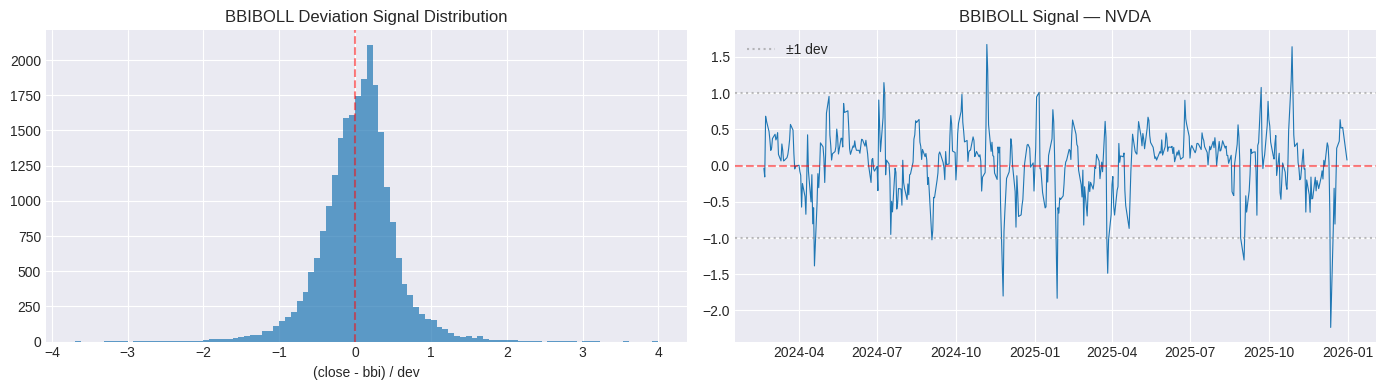

In [14]:
# Quick sanity check: distribution of signal values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

values = signal_df["value"].to_numpy()
axes[0].hist(values[np.isfinite(values)], bins=100, edgecolor="none", alpha=0.7)
axes[0].set_title("BBIBOLL Deviation Signal Distribution")
axes[0].set_xlabel("(close - bbi) / dev")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

# Signal over time for one stock
sample_ticker = "NVDA"
sample = signal_df.filter(pl.col("ticker") == sample_ticker).sort("date")
axes[1].plot(sample["date"].to_list(), sample["value"].to_list(), linewidth=0.8)
axes[1].set_title(f"BBIBOLL Signal — {sample_ticker}")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[1].axhline(1, color="gray", linestyle=":", alpha=0.5, label="±1 dev")
axes[1].axhline(-1, color="gray", linestyle=":", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Compute Forward Returns

Using `compute_forward_returns()` from `src/alpha/forward_returns.py`.
This computes the N-day simple return for each stock at each date.

In [15]:
HORIZONS = [1, 2, 5, 10, 20]

returns_df = compute_forward_returns(
    ohlcv,
    horizons=HORIZONS,
    price_col="close",
    date_col="timestamps",
    ticker_col="ticker",
)

print(f"Returns shape: {returns_df.shape}")
print(f"Columns: {returns_df.columns}")
returns_df.head(5)

Returns shape: (25733, 7)
Columns: ['date', 'ticker', 'forward_return_1d', 'forward_return_2d', 'forward_return_5d', 'forward_return_10d', 'forward_return_20d']


date,ticker,forward_return_1d,forward_return_2d,forward_return_5d,forward_return_10d,forward_return_20d
"datetime[ns, America/New_York]",str,f64,f64,f64,f64,f64
2024-01-02 00:00:00 EST,"""AAPL""",-0.007488,-0.020093,-0.002693,-0.015945,-0.00668
2024-01-03 00:00:00 EST,"""AAPL""",-0.0127,-0.016662,0.010529,0.023772,0.014166
2024-01-04 00:00:00 EST,"""AAPL""",-0.004013,0.020065,0.02023,0.053048,0.021659
2024-01-05 00:00:00 EST,"""AAPL""",0.024175,0.021857,0.026162,0.070151,0.035876
2024-01-08 00:00:00 EST,"""AAPL""",-0.002263,0.003395,-0.010401,0.051843,0.020155


## 5. Factor Analysis — Raw Signal

Run `FactorAnalyzer` on the raw BBIBOLL deviation signal.
This answers: *does this signal predict future cross-sectional returns?*

In [16]:
analyzer = FactorAnalyzer(signal_df, returns_df, min_observations=30)

# Full summary at 5-day horizon
raw_summary = analyzer.summary(horizon=5)


Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0216
  Std IC:           0.2023
  IR:              -0.1069
  t-stat:          -2.3027
  Hit Rate:          46.1%
  # Dates:             464
  Mean Turnover:    0.3106
  ✅ Statistically significant (|t| = 2.30 > 2)
  ⚠️  Weak factor (|IR| = 0.11 < 0.3)



In [17]:
# IC decay across horizons
decay_df = analyzer.ic_decay(horizons=HORIZONS)
print("IC Decay:")
print(decay_df)

IC Decay:
shape: (5, 5)
┌─────────┬───────────┬──────────┬───────────┬───────────┐
│ horizon ┆ mean_ic   ┆ std_ic   ┆ ir        ┆ t_stat    │
│ ---     ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ i64     ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ 1       ┆ -0.009135 ┆ 0.214853 ┆ -0.042515 ┆ -0.919746 │
│ 2       ┆ -0.009736 ┆ 0.21224  ┆ -0.045874 ┆ -0.991353 │
│ 5       ┆ -0.021627 ┆ 0.202311 ┆ -0.1069   ┆ -2.302687 │
│ 10      ┆ -0.034777 ┆ 0.214722 ┆ -0.161965 ┆ -3.469977 │
│ 20      ┆ -0.026634 ┆ 0.210677 ┆ -0.126421 ┆ -2.678818 │
└─────────┴───────────┴──────────┴───────────┴───────────┘


In [18]:
# Turnover
turnover_df = analyzer.turnover()
print(f"Mean daily turnover: {turnover_df['turnover'].mean():.4f}")
print(f"Turnover shape: {turnover_df.shape}")

Mean daily turnover: 0.3106
Turnover shape: (468, 3)


## 6. Visualizations

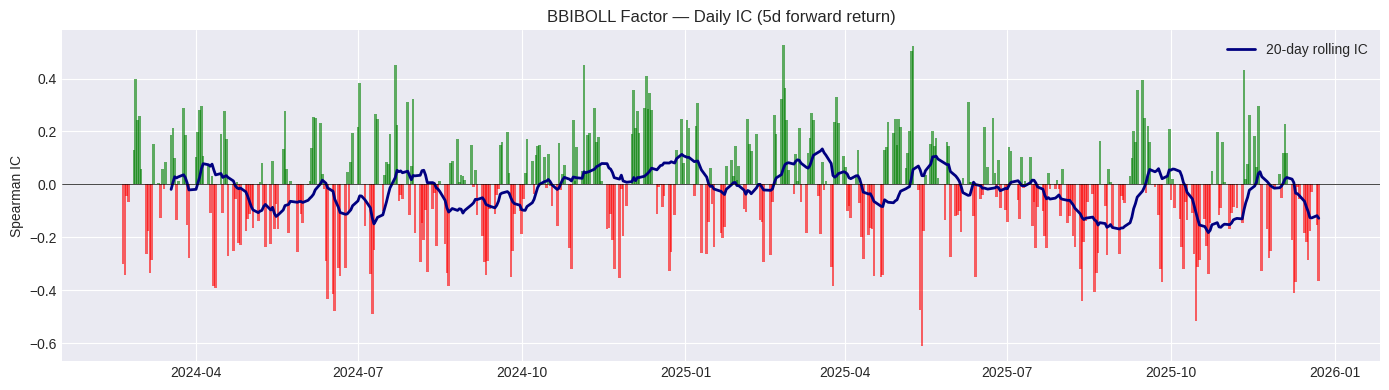

In [19]:
# --- Plot 1: IC Time Series ---
ic_ts = analyzer.ic_series(horizon=5)

fig, ax = plt.subplots(figsize=(14, 4))
dates = ic_ts["date"].to_list()
ics = ic_ts["ic"].to_numpy()

colors = ["green" if v > 0 else "red" for v in ics]
ax.bar(dates, ics, color=colors, alpha=0.6, width=1.5)

# Rolling mean IC
window = 20
if len(ics) >= window:
    rolling_ic = np.convolve(ics, np.ones(window)/window, mode="valid")
    ax.plot(dates[window-1:], rolling_ic, color="navy", linewidth=2, label=f"{window}-day rolling IC")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"BBIBOLL Factor — Daily IC (5d forward return)")
ax.set_ylabel("Spearman IC")
ax.legend()
plt.tight_layout()
plt.show()

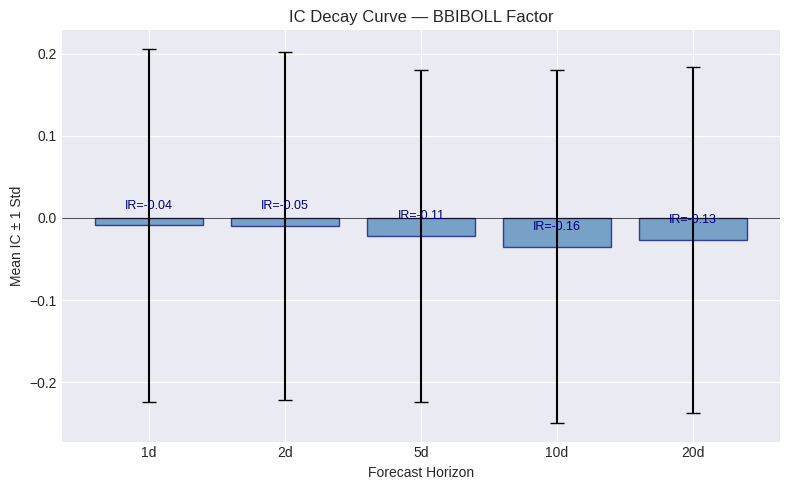

In [20]:
# --- Plot 2: IC Decay Curve ---
fig, ax = plt.subplots(figsize=(8, 5))

horizons_plot = decay_df["horizon"].to_list()
mean_ics = decay_df["mean_ic"].to_list()
std_ics = decay_df["std_ic"].to_list()

ax.bar(range(len(horizons_plot)), mean_ics, yerr=std_ics, 
       capsize=5, alpha=0.7, color="steelblue", edgecolor="navy")
ax.set_xticks(range(len(horizons_plot)))
ax.set_xticklabels([f"{h}d" for h in horizons_plot])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("IC Decay Curve — BBIBOLL Factor")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Mean IC ± 1 Std")

# Annotate IR values
irs = decay_df["ir"].to_list()
for i, ir_val in enumerate(irs):
    ax.annotate(f"IR={ir_val:.2f}", (i, mean_ics[i]), 
                textcoords="offset points", xytext=(0, 12), 
                ha="center", fontsize=9, color="navy")

plt.tight_layout()
plt.show()

Quantile Returns (5d horizon):
shape: (5, 3)
┌──────────┬─────────────┬────────────────┐
│ quantile ┆ mean_return ┆ n_observations │
│ ---      ┆ ---         ┆ ---            │
│ cat      ┆ f64         ┆ u32            │
╞══════════╪═════════════╪════════════════╡
│ 1        ┆ 0.004578    ┆ 5104           │
│ 2        ┆ 0.004585    ┆ 4640           │
│ 3        ┆ 0.004313    ┆ 4640           │
│ 4        ┆ 0.002799    ┆ 4640           │
│ 5        ┆ 0.002674    ┆ 4733           │
└──────────┴─────────────┴────────────────┘


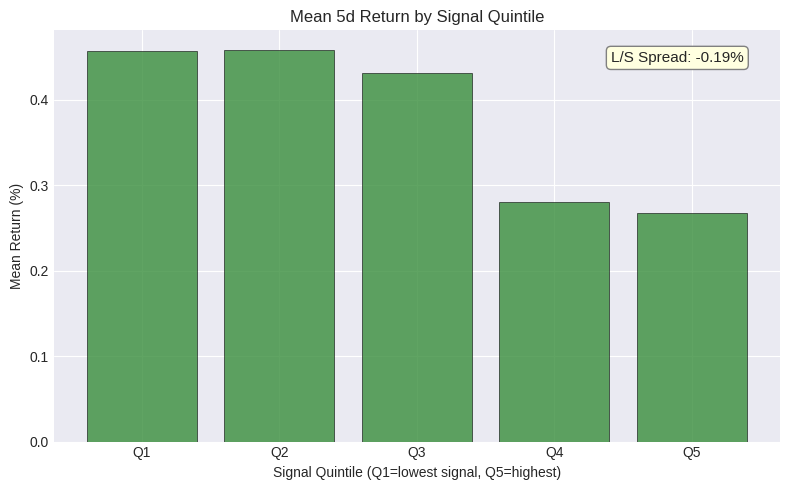

In [21]:
# --- Plot 3: Quantile Returns ---
try:
    quantile_df = analyzer.quantile_returns(horizon=5, n_quantiles=5)
    print("Quantile Returns (5d horizon):")
    print(quantile_df)

    fig, ax = plt.subplots(figsize=(8, 5))
    quantiles = quantile_df["quantile"].to_list()
    mean_rets = quantile_df["mean_return"].to_list()

    colors = ["#d32f2f" if r < 0 else "#388e3c" for r in mean_rets]
    ax.bar(range(len(quantiles)), [r * 100 for r in mean_rets], 
           color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(quantiles)))
    ax.set_xticklabels([f"Q{q}" for q in quantiles])
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Mean 5d Return by Signal Quintile")
    ax.set_xlabel("Signal Quintile (Q1=lowest signal, Q5=highest)")
    ax.set_ylabel("Mean Return (%)")

    # Long-short spread
    spread = (mean_rets[-1] - mean_rets[0]) * 100
    ax.annotate(f"L/S Spread: {spread:.2f}%", 
                xy=(0.95, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Quantile analysis failed (likely not enough data): {e}")

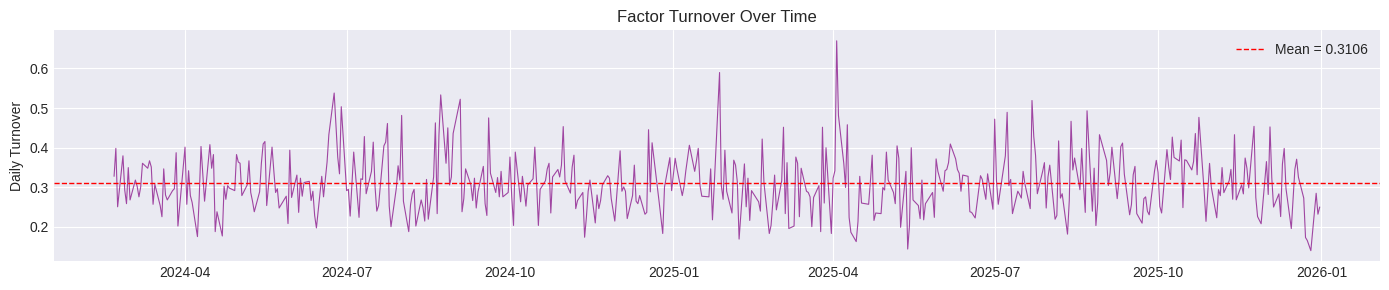

In [22]:
# --- Plot 4: Turnover over time ---
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(turnover_df["date"].to_list(), turnover_df["turnover"].to_list(), 
        linewidth=0.8, color="purple", alpha=0.7)
ax.axhline(turnover_df["turnover"].mean(), color="red", linestyle="--", 
           linewidth=1, label=f"Mean = {turnover_df['turnover'].mean():.4f}")
ax.set_title("Factor Turnover Over Time")
ax.set_ylabel("Daily Turnover")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Preprocessed Factor Comparison

Apply the preprocessing pipeline (winsorize + z-score) and compare
IC/IR against the raw signal.  Does preprocessing help?

In [24]:
# Preprocess: winsorize at 1%/99% + z-score
clean_signal = preprocess_factor(
    signal_df,
    winsorize_pct=0.01,
    method="zscore",
    neutralize=[],
)

print(f"Clean signal shape: {clean_signal.shape}")
clean_signal.select("value").describe()

Clean signal shape: (24017, 3)


statistic,value
str,f64
"""count""",24017.0
"""null_count""",0.0
"""mean""",4.0236e-17
"""std""",0.990209
"""min""",-3.885881
"""25%""",-0.613121
"""50%""",0.020608
"""75%""",0.575478
"""max""",5.368864


In [25]:
# Run FactorAnalyzer on the preprocessed signal
clean_analyzer = FactorAnalyzer(clean_signal, returns_df, min_observations=30)

print("=" * 50)
print("RAW SIGNAL")
print("=" * 50)
raw_summary = analyzer.summary(horizon=5)

print("\n")
print("=" * 50)
print("PREPROCESSED SIGNAL (winsorize + z-score)")
print("=" * 50)
clean_summary = clean_analyzer.summary(horizon=5)

RAW SIGNAL

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0216
  Std IC:           0.2023
  IR:              -0.1069
  t-stat:          -2.3027
  Hit Rate:          46.1%
  # Dates:             464
  Mean Turnover:    0.3106
  ✅ Statistically significant (|t| = 2.30 > 2)
  ⚠️  Weak factor (|IR| = 0.11 < 0.3)



PREPROCESSED SIGNAL (winsorize + z-score)

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0217
  Std IC:           0.2023
  IR:              -0.1070
  t-stat:          -2.3055
  Hit Rate:          46.3%
  # Dates:             464
  Mean Turnover:    0.3104
  ✅ Statistically significant (|t| = 2.31 > 2)
  ⚠️  Weak factor (|IR| = 0.11 < 0.3)



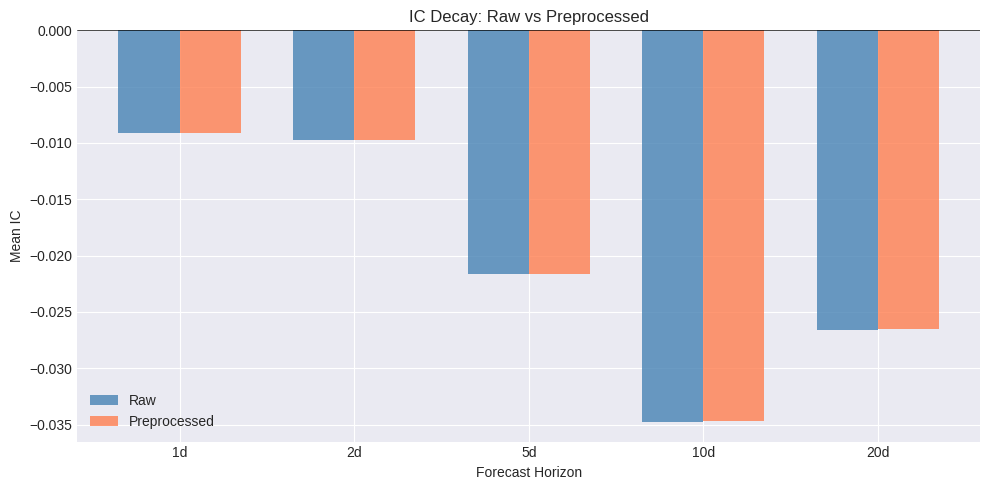

In [26]:
# Side-by-side IC decay comparison
raw_decay = analyzer.ic_decay(horizons=HORIZONS)
clean_decay = clean_analyzer.ic_decay(horizons=HORIZONS)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(HORIZONS))
width = 0.35

ax.bar(x - width/2, raw_decay["mean_ic"].to_list(), width, 
       label="Raw", alpha=0.8, color="steelblue")
ax.bar(x + width/2, clean_decay["mean_ic"].to_list(), width, 
       label="Preprocessed", alpha=0.8, color="coral")

ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("IC Decay: Raw vs Preprocessed")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Mean IC")
ax.legend()

plt.tight_layout()
plt.show()

## 8. Momentum Factor (for comparison)

Build a simple 20-day momentum factor to compare against BBIBOLL.
This also sets up the two-factor combination experiment from Chapter 12.

In [27]:
# 20-day momentum factor: (close_t / close_{t-20}) - 1
momentum_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (
            pl.col("close") / pl.col("close").shift(20).over("ticker") - 1
        ).alias("value")
    )
    .filter(pl.col("value").is_not_null() & pl.col("value").is_finite())
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)

# Preprocess momentum
clean_momentum = preprocess_factor(
    momentum_df,
    winsorize_pct=0.01,
    method="zscore",
    neutralize=[],
)

mom_analyzer = FactorAnalyzer(clean_momentum, returns_df, min_observations=30)
print("MOMENTUM (20d) — Preprocessed")
mom_summary = mom_analyzer.summary(horizon=5)

MOMENTUM (20d) — Preprocessed

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0150
  Std IC:           0.2402
  IR:              -0.0624
  t-stat:          -1.3623
  Hit Rate:          47.8%
  # Dates:             477
  Mean Turnover:    0.1474
  ⚠️  Not significant (|t| = 1.36 < 2)
  ⚠️  Weak factor (|IR| = 0.06 < 0.3)



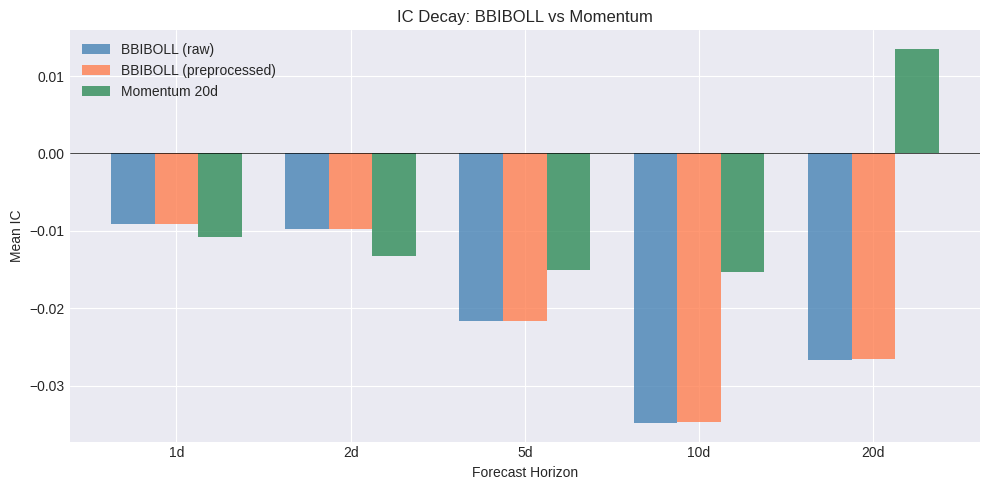

In [28]:
# Three-way IC decay comparison
mom_decay = mom_analyzer.ic_decay(horizons=HORIZONS)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(HORIZONS))
width = 0.25

ax.bar(x - width, raw_decay["mean_ic"].to_list(), width,
       label="BBIBOLL (raw)", alpha=0.8, color="steelblue")
ax.bar(x, clean_decay["mean_ic"].to_list(), width,
       label="BBIBOLL (preprocessed)", alpha=0.8, color="coral")
ax.bar(x + width, mom_decay["mean_ic"].to_list(), width,
       label="Momentum 20d", alpha=0.8, color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("IC Decay: BBIBOLL vs Momentum")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Mean IC")
ax.legend()

plt.tight_layout()
plt.show()

## 9. Two-Factor Combination (Preview)

Combine BBIBOLL + Momentum using equal-weight.
If they are negatively correlated (mean-reversion vs. trend-following),
the composite should have a higher IR than either alone.

In [29]:
from alpha.combination import combine_factors

# Equal-weight composite
composite = combine_factors(
    factors=[clean_signal, clean_momentum],
    method="equal_weight",
)

combo_analyzer = FactorAnalyzer(composite, returns_df, min_observations=30)
print("COMPOSITE (BBIBOLL + Momentum, equal-weight)")
combo_summary = combo_analyzer.summary(horizon=5)

COMPOSITE (BBIBOLL + Momentum, equal-weight)

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0151
  Std IC:           0.2236
  IR:              -0.0677
  t-stat:          -1.4583
  Hit Rate:          47.2%
  # Dates:             464
  Mean Turnover:    0.2435
  ⚠️  Not significant (|t| = 1.46 < 2)
  ⚠️  Weak factor (|IR| = 0.07 < 0.3)



In [30]:
# Summary comparison table
comparison = pl.DataFrame({
    "Factor": ["BBIBOLL (raw)", "BBIBOLL (preprocessed)", "Momentum 20d", "Composite (EW)"],
    "Mean IC": [raw_summary["mean_ic"], clean_summary["mean_ic"], mom_summary["mean_ic"], combo_summary["mean_ic"]],
    "IR": [raw_summary["ir"], clean_summary["ir"], mom_summary["ir"], combo_summary["ir"]],
    "t-stat": [raw_summary["t_stat"], clean_summary["t_stat"], mom_summary["t_stat"], combo_summary["t_stat"]],
    "Hit Rate %": [raw_summary["hit_rate"], clean_summary["hit_rate"], mom_summary["hit_rate"], combo_summary["hit_rate"]],
    "Turnover": [raw_summary["mean_turnover"], clean_summary["mean_turnover"], mom_summary["mean_turnover"], combo_summary["mean_turnover"]],
})

print("\n📊 Factor Comparison Table (5d horizon):")
print(comparison)


📊 Factor Comparison Table (5d horizon):
shape: (4, 6)
┌────────────────────────┬───────────┬───────────┬───────────┬────────────┬──────────┐
│ Factor                 ┆ Mean IC   ┆ IR        ┆ t-stat    ┆ Hit Rate % ┆ Turnover │
│ ---                    ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---      │
│ str                    ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64      │
╞════════════════════════╪═══════════╪═══════════╪═══════════╪════════════╪══════════╡
│ BBIBOLL (raw)          ┆ -0.021627 ┆ -0.1069   ┆ -2.302687 ┆ 46.12069   ┆ 0.310592 │
│ BBIBOLL (preprocessed) ┆ -0.021651 ┆ -0.107029 ┆ -2.305465 ┆ 46.336207  ┆ 0.310416 │
│ Momentum 20d           ┆ -0.014981 ┆ -0.062374 ┆ -1.362269 ┆ 47.798742  ┆ 0.147417 │
│ Composite (EW)         ┆ -0.015135 ┆ -0.067701 ┆ -1.458319 ┆ 47.198276  ┆ 0.243456 │
└────────────────────────┴───────────┴───────────┴───────────┴────────────┴──────────┘


## 10. Reflection

### Questions to Answer

1. **Is the BBIBOLL factor statistically significant?**  
   Check: |t-stat| > 2 and hit rate > 50%.

2. **What is the signal's natural frequency?**  
   Look at the IC decay curve: does IC peak at 1d, 5d, or longer?

3. **Does preprocessing improve IR?**  
   Compare raw vs preprocessed IC/IR.

4. **Are BBIBOLL and Momentum diversifying?**  
   If the composite IR > max(individual IRs), combination works.

5. **Is the turnover reasonable?**  
   Mean turnover > 0.5 suggests very short-term signal that may be
   eroded by transaction costs.

### Observations

*Fill in after running the notebook:*

- Mean IC (5d): ___
- IR (5d): ___
- IC peak horizon: ___
- Preprocessing impact: ___
- Combination benefit: ___
- Overall verdict: ___